In [12]:
import numpy as np
import matplotlib.pyplot as plt

In [13]:
# necessary fonctions

def plot_3d_raw(X, title="Raw 3D data"):
    fig = plt.figure(figsize=(9, 7))
    ax = fig.add_subplot(111, projection="3d")
    ax.scatter(X[:, 0], X[:, 1], X[:, 2], s=12, alpha=0.7)
    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("X3")
    plt.tight_layout()
    plt.show()

def plot_3d_clusters(X, train_labels, X_test=None, test_labels=None, title="GMM clustering result"):
    fig = plt.figure(figsize=(10, 8))
    ax = fig.add_subplot(111, projection="3d")

    unique_labels = np.unique(train_labels)

    # Training points
    for lab in unique_labels:
        idx = train_labels == lab
        ax.scatter(
            X[idx, 0], X[idx, 1], X[idx, 2],
            s=14, alpha=0.65,
            label=f"Train cluster {lab + 1}"
        )

    # Test points
    if X_test is not None and test_labels is not None:
        for i, point in enumerate(X_test):
            ax.scatter(
                point[0], point[1], point[2],
                s=180, marker="X", edgecolors="black", linewidths=1.5,
                label=f"Test x{i+1} -> C{test_labels[i] + 1}"
            )
            ax.text(
                point[0], point[1], point[2],
                f" x{i+1}:C{test_labels[i] + 1}",
                fontsize=9
            )

    ax.set_title(title)
    ax.set_xlabel("X1")
    ax.set_ylabel("X2")
    ax.set_zlabel("X3")
    ax.legend(loc="best", fontsize=8)
    plt.tight_layout()
    plt.show()


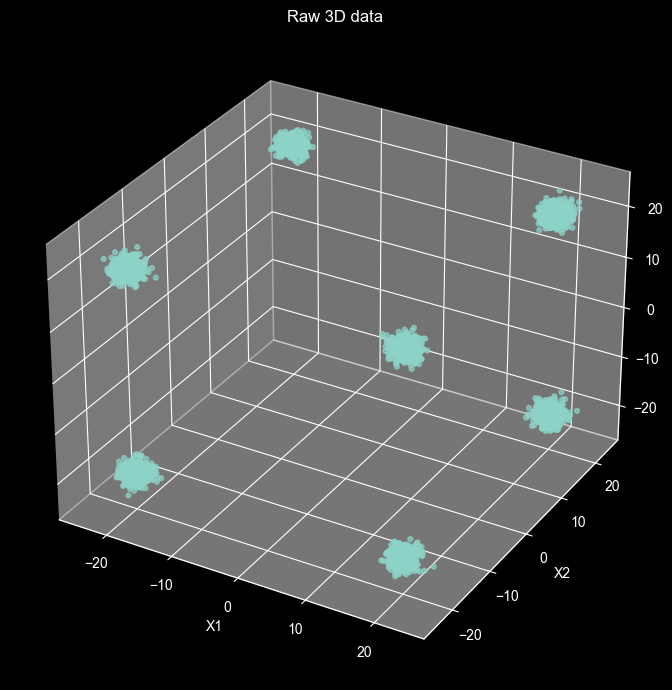

In [14]:
# 2) Plot the raw data in 3D to guess J
X = np.loadtxt("dataGMM.txt")
plot_3d_raw(X)

In [15]:
J = 7

MAX_ITER = 200
TOL = 1e-5
reg_covar = 1e-6
N_INIT = 3
RANDOM_SEED = 42

In [16]:
# defining the initial information and hyperparameters

def Marginal_likelihood(a, axis=None, keepdims=False):
    a_max = np.max(a, axis=axis, keepdims=True)
    out = a_max + np.log(np.sum(np.exp(a - a_max), axis=axis, keepdims=True))
    if not keepdims:
        out = np.squeeze(out, axis=axis)
    return out

def Conditional_likelihood(X, mu, Sigma,reg_covar=1e-6):

    I, N = X.shape
    Sigma = Sigma + reg_covar * np.eye(N)

    sign, logdet = np.linalg.slogdet(Sigma)
    if sign <= 0:
        Sigma = Sigma + 10 * reg_covar * np.eye(N)
        sign, logdet = np.linalg.slogdet(Sigma)

    invSigma = np.linalg.inv(Sigma)
    diff = X - mu
    maha = np.sum((diff @ invSigma) * diff, axis=1)

    return -0.5 * (N * np.log(2 * np.pi) + logdet + maha)



In [17]:
def initialize_parameters(X, K, reg_covar, rng):
    I, N = X.shape

    # Prior probabilities P(z=j)
    phi = np.ones(K) / K

    # Means
    chosen = rng.choice(I, K, replace=False)
    mu = X[chosen].copy()

    # Covariances
    overall_cov = np.cov(X.T) + reg_covar * np.eye(N)
    Sigma = np.array([overall_cov.copy() for _ in range(K)])

    return phi, mu, Sigma

def e_step(X, phi, mu, Sigma, K):
    
    # E-step: w_j^(i) = P(z=j | x^(i))
    
    I = X.shape[0]
    log_resp = np.zeros((I, K))

    for j in range(K):
        # log P(x, z=j) = log P(z=j) + log P(x|z=j)
        log_resp[:, j] = np.log(phi[j] + 1e-16) + Conditional_likelihood(X, mu[j], Sigma[j], reg_covar)

    # log P(x)
    log_norm = Marginal_likelihood(log_resp, axis=1, keepdims=True)

    # log posterior = log P(z=j|x)
    log_resp = log_resp - log_norm

    # posterior / responsibilities
    resp = np.exp(log_resp)

    # total log-likelihood
    log_likelihood = np.sum(log_norm)

    return resp, log_likelihood


def m_step(X, resp, K, reg_covar):
    
    # M-step: update phi, mu, Sigma
    
    I, N = X.shape
    Nk = resp.sum(axis=0) + 1e-16

    # phi_j
    phi = Nk / I

    # mu_j
    mu = (resp.T @ X) / Nk[:, None]

    # Sigma_j
    Sigma = np.zeros((K, N, N))
    for j in range(K):
        diff = X - mu[j]
        Sigma[j] = (resp[:, j][:, None] * diff).T @ diff / Nk[j]
        Sigma[j] += reg_covar * np.eye(N)

    return phi, mu, Sigma



In [18]:
def fit_gmm(X, K, max_iter=100, tol=1e-4, reg_covar=1e-6, n_init=1, random_state=None):
    
    # Full EM loop with several random initializations.
    best_ll = -np.inf
    best_phi = None
    best_mu = None
    best_Sigma = None
    best_resp = None
    best_history = None

    rng_master = np.random.default_rng(random_state)

    for _ in range(n_init):
        rng = np.random.default_rng(rng_master.integers(0, 1_000_000))

        phi, mu, Sigma = initialize_parameters(X, K, reg_covar, rng)
        history = []
        prev_ll = None

        for _ in range(max_iter):
            resp, ll = e_step(X, phi, mu, Sigma, K)
            phi, mu, Sigma = m_step(X, resp, K, reg_covar)

            history.append(ll)

            if prev_ll is not None and abs(ll - prev_ll) < tol:
                break
            prev_ll = ll

        if history[-1] > best_ll:
            best_ll = history[-1]
            best_phi = phi.copy()
            best_mu = mu.copy()
            best_Sigma = Sigma.copy()
            best_resp = resp.copy()
            best_history = history.copy()

    return {
        "phi": best_phi,
        "mu": best_mu,
        "Sigma": best_Sigma,
        "resp": best_resp,
        "log_likelihood_history": best_history,
        "best_log_likelihood": best_ll
    }


In [19]:
def predict_proba_gmm(X, phi, mu, Sigma, K):
    
    # Returns posterior probabilities P(z=j | x)
    
    resp, _ = e_step(X, phi, mu, Sigma, K)
    return resp


def predict_gmm(X, phi, mu, Sigma, K):
    
    # Returns hard cluster assignment: argmax_j P(z=j | x)
    
    resp = predict_proba_gmm(X, phi, mu, Sigma, K)
    return np.argmax(resp, axis=1)


def score_samples_gmm(X, phi, mu, Sigma, K):
    
    # Returns log P(x) for each sample
    
    I = X.shape[0]
    log_prob = np.zeros((I, K))

    for j in range(K):
        log_prob[:, j] = np.log(phi[j] + 1e-16) + Conditional_likelihood(X, mu[j], Sigma[j], reg_covar)

    return Marginal_likelihood(log_prob, axis=1)

In [20]:
    # 3) Train GMM with all training data
gmm = fit_gmm(
    X,
    K=J,
    max_iter=MAX_ITER,
    tol=TOL,
    reg_covar=reg_covar,
    n_init=N_INIT,
    random_state=RANDOM_SEED
)

phi = gmm["phi"]
mu = gmm["mu"]
Sigma = gmm["Sigma"]


train_labels = predict_gmm(X, phi, mu, Sigma, J)

print("\n=== Trained GMM parameters ===")
print("Mixture weights phi:")
print(phi)

print("\nMeans mu:")
print(mu)

print("\nCovariance matrices Sigma:")
for j in range(J):
    print(f"\nSigma[{j+1}] =\n{Sigma[j]}")





=== Trained GMM parameters ===
Mixture weights phi:
[0.14285714 0.14285714 0.14285714 0.14285714 0.14285714 0.14285714
 0.14285714]

Means mu:
[[ 20.04948337  19.97766057 -19.97389446]
 [ 19.95983425 -19.96594332 -19.99742827]
 [-19.98732848 -20.00270967 -19.98827483]
 [-19.94165233  20.01708231  20.01345896]
 [ 20.00754005  19.96567755  20.0146522 ]
 [-20.03768392 -20.0262799   20.0781031 ]
 [ 19.95870677 -19.92991718  20.09197888]]

Covariance matrices Sigma:

Sigma[1] =
[[ 0.95896414 -0.02060549 -0.02635202]
 [-0.02060549  1.1139018  -0.0126093 ]
 [-0.02635202 -0.0126093   1.0463471 ]]

Sigma[2] =
[[ 0.91204094 -0.1136267  -0.00813604]
 [-0.1136267   0.98224061 -0.00565752]
 [-0.00813604 -0.00565752  0.87540968]]

Sigma[3] =
[[ 1.01178337 -0.02557693  0.05257906]
 [-0.02557693  0.95881047 -0.05545952]
 [ 0.05257906 -0.05545952  0.99661714]]

Sigma[4] =
[[ 0.93571573 -0.02897199 -0.06647057]
 [-0.02897199  1.00034213 -0.01916926]
 [-0.06647057 -0.01916926  0.96099148]]

Sigma[5] =
[

In [21]:
# 4) Test data
X_test = np.array([
    [20,  20,  20],
    [-20, 20,  20],
    [20,  20, -20],
    [20, -20,  20],
    [20, -20, -20]
], dtype=float)

test_resp = predict_proba_gmm(X_test, phi, mu, Sigma, J)
test_labels = predict_gmm(X_test, phi, mu, Sigma, J)
test_log_density = score_samples_gmm(X_test, phi, mu, Sigma, J)

print("\n=== Test results ===")
for i, x in enumerate(X_test):
    print(f"\nTest point x{i+1} = {x}")
    print("Responsibilities:", test_resp[i])
    print("Predicted cluster ID:", test_labels[i] + 1)
    print("Log-density:", test_log_density[i])



=== Test results ===

Test point x1 = [20. 20. 20.]
Responsibilities: [0. 0. 0. 0. 1. 0. 0.]
Predicted cluster ID: 5
Log-density: -4.737118760425735

Test point x2 = [-20.  20.  20.]
Responsibilities: [0. 0. 0. 1. 0. 0. 0.]
Predicted cluster ID: 4
Log-density: -4.648801759715971

Test point x3 = [ 20.  20. -20.]
Responsibilities: [1. 0. 0. 0. 0. 0. 0.]
Predicted cluster ID: 1
Log-density: -4.759578123902319

Test point x4 = [ 20. -20.  20.]
Responsibilities: [0. 0. 0. 0. 0. 0. 1.]
Predicted cluster ID: 7
Log-density: -4.621928454540411

Test point x5 = [ 20. -20. -20.]
Responsibilities: [1.47098048e-312 1.00000000e+000 0.00000000e+000 0.00000000e+000
 0.00000000e+000 0.00000000e+000 0.00000000e+000]
Predicted cluster ID: 2
Log-density: -4.575198539646253


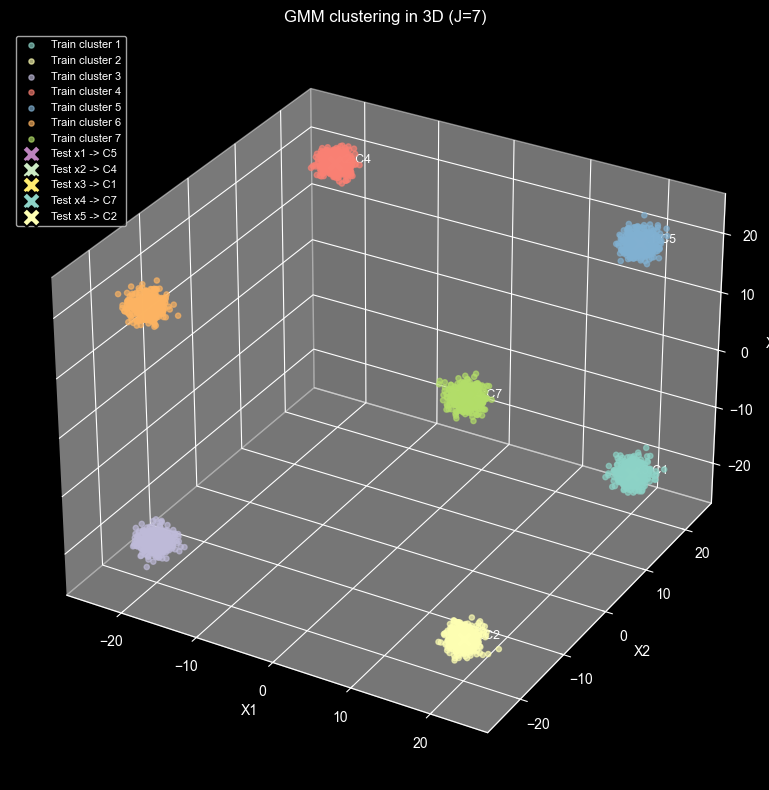

In [22]:

# 5) Plot both training and test results
plot_3d_clusters(
    X,
    train_labels,
    X_test=X_test,
    test_labels=test_labels,
    title=f"GMM clustering in 3D (J={J})"
)